<a href="https://colab.research.google.com/github/NimrahImran/Customer_Segmentation_KMeans_Clustering/blob/main/Customer_Segmentation_KMeans_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🎯 1. Problem Statement

**Objective:** [Group mall customers into meaningful segments based on their annual income and spending patterns, without any predefined labels]

**Dataset:** [Mall Customer Segmentation dataset (Mall_Customers.csv) — 200 records, 5 columns]

**Problem Type:** [Unsupervised Learning (Clustering) — no target variable]

**Business Relevance:** [Enables targeted marketing strategies by identifying distinct customer groups (e.g. high-income low-spenders, budget-conscious shoppers, big spenders), helping businesses tailor promotions and improve customer retention]

**Success Criteria:** [Silhouette Score (higher is better, range -1 to 1) → Achieved: 0.5584]


## 📦 2. Import Libraries

In [83]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
COLOR_CYCLE = sns.color_palette("husl", 12)

In [85]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [86]:
# Clustering algorithms
from sklearn.cluster import (KMeans, AgglomerativeClustering, DBSCAN, MeanShift,
                              OPTICS, Birch, SpectralClustering, AffinityPropagation)
from sklearn.mixture import GaussianMixture

In [87]:
# Dimensionality reduction algorithms
from sklearn.decomposition import PCA, KernelPCA, IncrementalPCA, TruncatedSVD
from sklearn.manifold import TSNE
try:
    from umap import UMAP
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

In [88]:
# Evaluation metrics and utilities
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
import joblib

## ⚙️ 3. Configuration — edit only these 4 variables

In [89]:
# ============= EDIT ONLY THESE 4 VARIABLES =============
DATA_PATH = "/content/Mall_Customers.csv"
PROBLEM_TYPE = "clustering"          # "clustering" or "dimensionality_reduction"
ALGORITHM_NAME = "kmeans"
RANDOM_SEED = 42
# =========================================================

## 📂 4. Data Loading

In [90]:
try:
    df = pd.read_csv(DATA_PATH)
    assert df.shape[0] > 0, "Dataset is empty."
except FileNotFoundError:
    raise FileNotFoundError(f"Could not find file at DATA_PATH='{DATA_PATH}'. Check the path and try again.")
print("Shape:", df.shape)
df.head()

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [91]:
df = df[["Annual Income (k$)", "Spending Score (1-100)"]]
print(df.shape)
df.head()

(200, 2)


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Annual Income (k$)      200 non-null    int64
 1   Spending Score (1-100)  200 non-null    int64
dtypes: int64(2)
memory usage: 3.3 KB


In [93]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.0,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.0,99.0


In [94]:
pd.DataFrame({"dtype": df.dtypes, "unique_values": df.nunique()})

,dtype,unique_values
Annual Income (k$),int64,64
Spending Score (1-100),int64,84


## 🧹 5. Data Cleaning

In [95]:
df.columns = df.columns.str.strip().str.lower()

In [96]:
# Automatically detect and drop ID-like columns (unique identifiers, not continuous measurements)
id_like_cols = [c for c in df.columns if df[c].nunique() == len(df) and not pd.api.types.is_float_dtype(df[c])]
if id_like_cols:
    df = df.drop(columns=id_like_cols)
    print(f"Dropped ID-like columns: {id_like_cols}")
else:
    print("No ID-like columns detected.")

No ID-like columns detected.


In [97]:
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicate rows removed: {duplicate_count}")

Duplicate rows removed: 4


In [98]:
constant_cols = [c for c in df.columns if df[c].nunique() <= 1]
if constant_cols:
    df = df.drop(columns=constant_cols)
    print(f"Dropped constant columns: {constant_cols}")
else:
    print("No constant columns detected.")

No constant columns detected.


In [99]:
missing_summary = df.isnull().sum()
missing_percent = (missing_summary / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing_summary, "missing_%": missing_percent})

,missing_count,missing_%
annual income (k$),0,0.0
spending score (1-100),0,0.0


In [100]:
# Intelligent missing value imputation: median for skewed numeric, mean for near-symmetric, mode for categorical
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().sum() > 0:
        fill_value = df[col].median() if abs(df[col].skew()) > 1 else df[col].mean()
        df[col] = df[col].fillna(fill_value)
for col in df.select_dtypes(include="object").columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])
print("Missing values handled (numeric: median/mean based on skew, categorical: mode).")

Missing values handled (numeric: median/mean based on skew, categorical: mode).


## 📊 6. Exploratory Data Analysis (EDA)

### 6.1 Dashboard Overview

In [101]:
GRADIENT = ["#667EEA", "#764BA2", "#F093FB", "#4FACFE", "#00F2FE", "#43E97B", "#FA8BFF", "#2BD2FF"]
numeric_cols_all = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols_all = df.select_dtypes(include="object").columns.tolist()
print(f"Numeric columns: {len(numeric_cols_all)} | Categorical columns: {len(categorical_cols_all)}")

Numeric columns: 2 | Categorical columns: 0


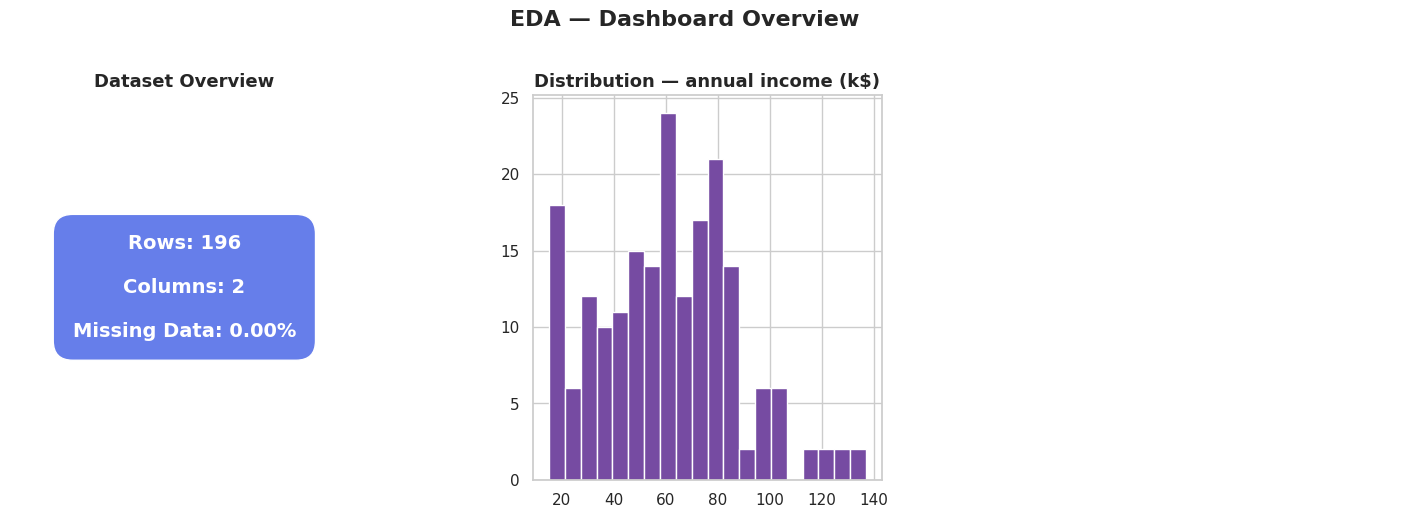

In [102]:
fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(1, 3, wspace=0.5)

ax1 = fig.add_subplot(gs[0, 0])
ax1.axis("off")
missing_pct = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100)
kpi_text = f"Rows: {df.shape[0]:,}\n\nColumns: {df.shape[1]}\n\nMissing Data: {missing_pct:.2f}%"
ax1.text(0.5, 0.5, kpi_text, fontsize=14, weight="bold", ha="center", va="center",
         color="white", bbox=dict(boxstyle="round,pad=1", facecolor=GRADIENT[0]))
ax1.set_title("Dataset Overview", fontsize=13, weight="bold")

ax2 = fig.add_subplot(gs[0, 1])
if numeric_cols_all:
    ax2.hist(df[numeric_cols_all[0]], bins=20, color=GRADIENT[1], edgecolor="white")
    ax2.set_title(f"Distribution — {numeric_cols_all[0]}", fontsize=13, weight="bold")
else:
    ax2.axis("off")

ax3 = fig.add_subplot(gs[0, 2])
if categorical_cols_all:
    cat_counts = df[categorical_cols_all[0]].value_counts().head(6)
    wedges, _, _ = ax3.pie(cat_counts.values, autopct="%1.0f%%", colors=GRADIENT, textprops={"fontsize": 8})
    ax3.legend(wedges, cat_counts.index, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=7)
    ax3.set_title(f"{categorical_cols_all[0].title()} Breakdown", fontsize=13, weight="bold")
else:
    ax3.axis("off")

plt.suptitle("EDA — Dashboard Overview", fontsize=16, weight="bold", y=1.05)
plt.tight_layout()
plt.show()

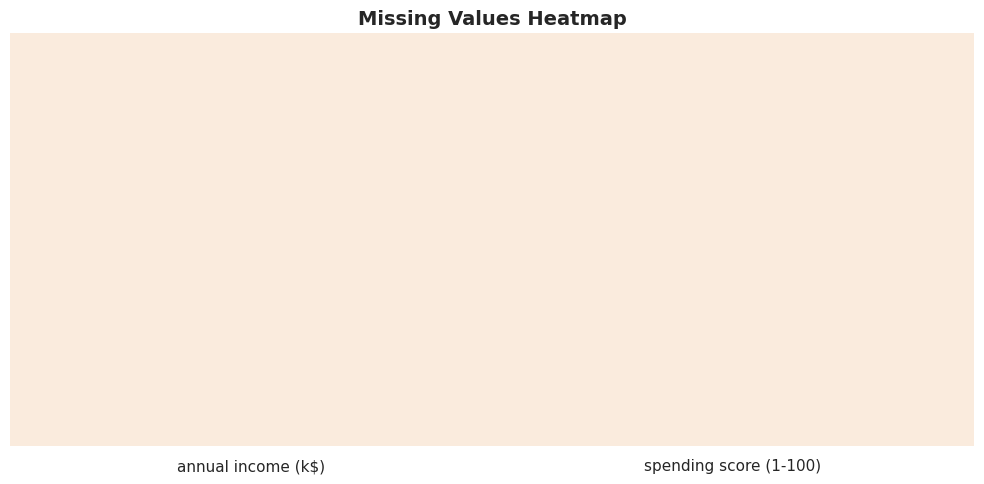

In [103]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="rocket_r", yticklabels=False)
plt.title("Missing Values Heatmap", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

### 6.2 Correlation Analysis

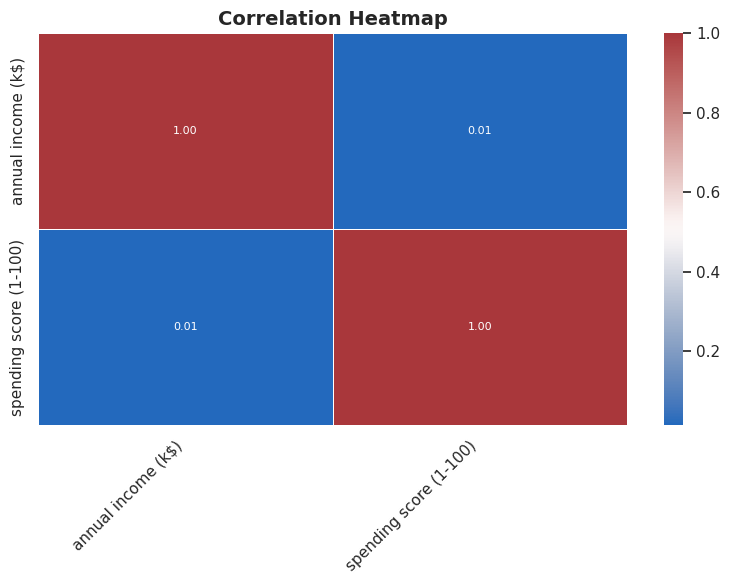

In [104]:
if len(numeric_cols_all) == 0:
    print("No numeric columns found — correlation heatmap skipped.")
else:
    heatmap_cols = numeric_cols_all[:20]
    if len(numeric_cols_all) > 20:
        print(f"Dataset has {len(numeric_cols_all)} numeric columns — showing the first 20 for readability.")
    plt.figure(figsize=(max(8, len(heatmap_cols) * 0.8), max(6, len(heatmap_cols) * 0.6)))
    sns.heatmap(df[heatmap_cols].corr(), annot=True, cmap="vlag", fmt=".2f", linewidths=0.5, annot_kws={"size": 8})
    plt.title("Correlation Heatmap", fontsize=14, weight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

### 6.3 Distribution & Skewness Analysis

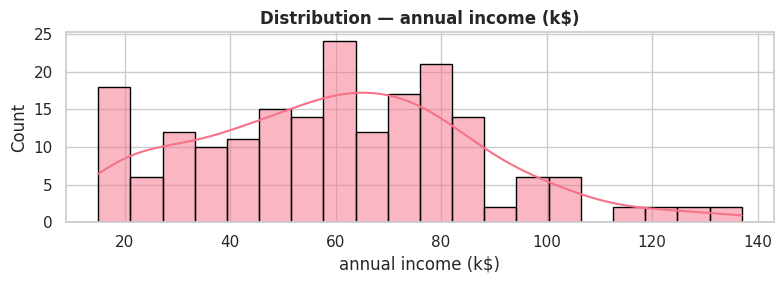

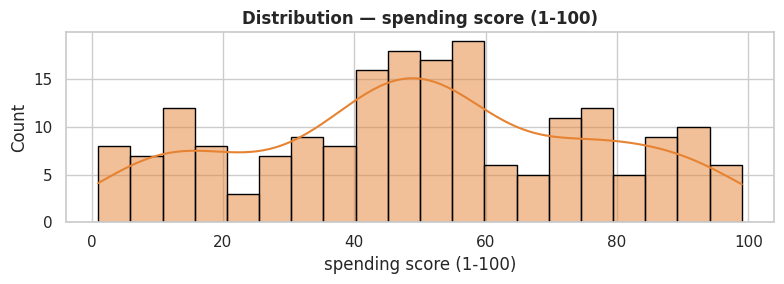

In [105]:
MAX_FEATURE_CHARTS = 12
plot_features = numeric_cols_all[:MAX_FEATURE_CHARTS]
if len(numeric_cols_all) > MAX_FEATURE_CHARTS:
    print(f"Showing distributions for the first {MAX_FEATURE_CHARTS} of {len(numeric_cols_all)} numeric features.")
for i, col in enumerate(plot_features):
    plt.figure(figsize=(8, 3))
    sns.histplot(df[col], bins=20, kde=True, color=COLOR_CYCLE[i % len(COLOR_CYCLE)], edgecolor="black")
    plt.title(f"Distribution — {col}", fontsize=12, weight="bold")
    plt.tight_layout()
    plt.show()

In [106]:
if plot_features:
    skew_table = df[plot_features].skew().sort_values(key=abs, ascending=False)
    pd.DataFrame({"skewness": skew_table.round(3)})
else:
    print("No numeric features available for skewness analysis.")

### 6.4 Outlier Detection (Boxplots)

Boxplots BEFORE outlier treatment:


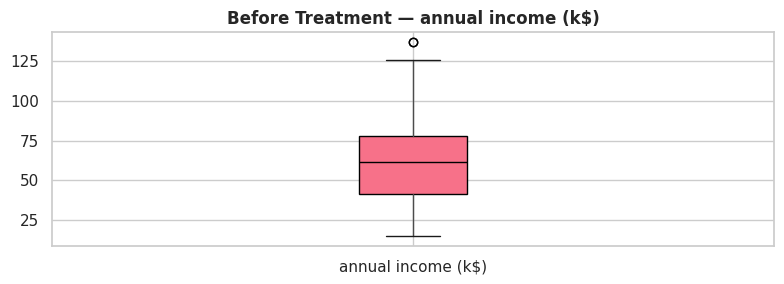

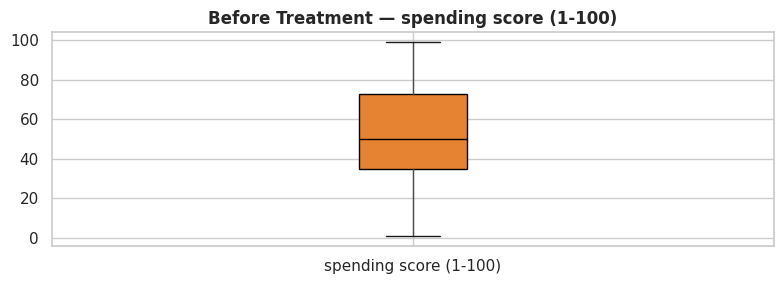

In [107]:
print("Boxplots BEFORE outlier treatment:")
for i, col in enumerate(plot_features):
    plt.figure(figsize=(8, 3))
    df.boxplot(column=col, patch_artist=True,
               boxprops=dict(facecolor=COLOR_CYCLE[i % len(COLOR_CYCLE)]), medianprops=dict(color="black"))
    plt.title(f"Before Treatment — {col}", fontsize=12, weight="bold")
    plt.tight_layout()
    plt.show()

### 6.5 Categorical Feature Analysis

In [108]:
for col in categorical_cols_all:
    value_counts = df[col].value_counts()
    if len(value_counts) > 15:
        top_categories = value_counts.head(15).index
        plot_series = df[col].where(df[col].isin(top_categories), "Other")
        print(f"'{col}' has {len(value_counts)} categories — showing top 15.")
    else:
        plot_series = df[col]
    plt.figure(figsize=(8, 4))
    sns.countplot(x=plot_series, hue=plot_series, palette="Set2", legend=False,
                  order=plot_series.value_counts().index)
    plt.title(f"Distribution of {col}", fontsize=12, weight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

### 6.6 Pairplot of Key Numeric Features

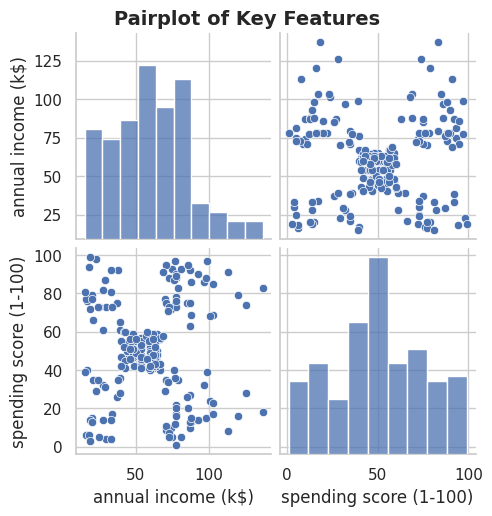

In [109]:
if len(plot_features) == 0:
    print("No numeric features found — pairplot skipped.")
else:
    sample_df = df.sample(min(300, len(df)), random_state=RANDOM_SEED)
    sns.pairplot(sample_df[plot_features[:4]], palette="husl")
    plt.suptitle("Pairplot of Key Features", y=1.02, fontsize=14, weight="bold")
    plt.show()

## 🎯 7. Outlier Treatment
Numeric features are automatically capped using the IQR method (Winsorization).
Binary/constant columns (IQR = 0) are skipped to avoid destroying signal.

In [110]:
APPLY_OUTLIER_CLIPPING = True    # set to False to disable outlier handling entirely
if APPLY_OUTLIER_CLIPPING:
    for col in plot_features:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        if IQR == 0:
            continue
        df[col] = df[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)
    print("Outlier capping applied (binary/constant columns skipped).")
else:
    print("Outlier clipping disabled by configuration.")

Outlier capping applied (binary/constant columns skipped).


Boxplots AFTER outlier treatment:


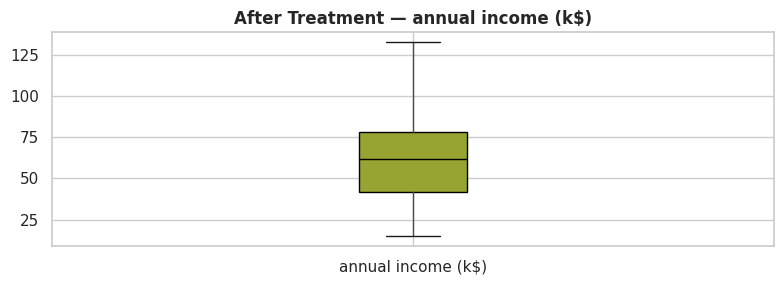

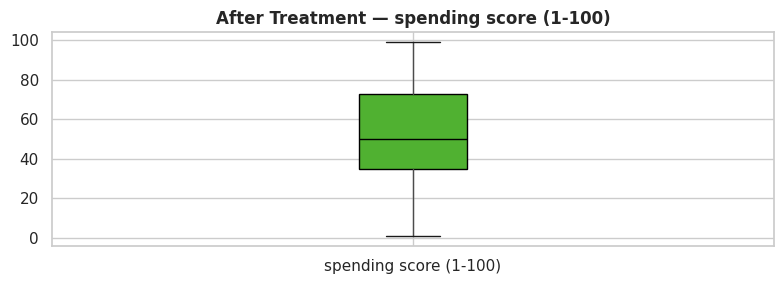

In [111]:
print("Boxplots AFTER outlier treatment:")
for i, col in enumerate(plot_features):
    plt.figure(figsize=(8, 3))
    df.boxplot(column=col, patch_artist=True,
               boxprops=dict(facecolor=COLOR_CYCLE[(i+3) % len(COLOR_CYCLE)]), medianprops=dict(color="black"))
    plt.title(f"After Treatment — {col}", fontsize=12, weight="bold")
    plt.tight_layout()
    plt.show()

## 🛠️ 8. Feature Engineering

In [112]:
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include="object").columns.tolist()
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['annual income (k$)', 'spending score (1-100)']
Categorical: []


In [113]:
# Drop one feature from each highly correlated numeric pair (correlation > 0.95)
if len(numeric_features) > 1:
    corr_matrix = df[numeric_features].corr().abs()
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.95)]
    if high_corr_drop:
        df = df.drop(columns=high_corr_drop)
        numeric_features = [c for c in numeric_features if c not in high_corr_drop]
        print(f"Dropped highly correlated features (>0.95): {high_corr_drop}")
    else:
        print("No highly correlated feature pairs found.")

No highly correlated feature pairs found.


In [114]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [115]:
X_processed = preprocessor.fit_transform(df)
feature_names_processed = preprocessor.get_feature_names_out()
print("Processed feature matrix shape:", X_processed.shape)

Processed feature matrix shape: (196, 2)


## 🤖 9. Model Selection

In [116]:
clustering_algorithms = {
    "kmeans": KMeans(n_clusters=5, random_state=RANDOM_SEED, n_init=10),
    "hierarchical": AgglomerativeClustering(n_clusters=3),
    "dbscan": DBSCAN(eps=0.8, min_samples=5),
    "mean_shift": MeanShift(),
    "optics": OPTICS(min_samples=5),
    "birch": Birch(n_clusters=3),
    "gmm": GaussianMixture(n_components=3, random_state=RANDOM_SEED),
    "spectral": SpectralClustering(n_clusters=3, random_state=RANDOM_SEED, affinity="nearest_neighbors"),
    "affinity_propagation": AffinityPropagation(random_state=RANDOM_SEED)
}

dim_reduction_algorithms = {
    "pca": PCA(n_components=2, random_state=RANDOM_SEED),
    "kernel_pca": KernelPCA(n_components=2, kernel="rbf", random_state=RANDOM_SEED),
    "incremental_pca": IncrementalPCA(n_components=2),
    "truncated_svd": TruncatedSVD(n_components=2, random_state=RANDOM_SEED),
    "tsne": TSNE(n_components=2, random_state=RANDOM_SEED, init="pca")
}
if UMAP_AVAILABLE:
    dim_reduction_algorithms["umap"] = UMAP(n_components=2, random_state=RANDOM_SEED)

In [117]:
algorithm_pool = clustering_algorithms if PROBLEM_TYPE == "clustering" else dim_reduction_algorithms
if ALGORITHM_NAME not in algorithm_pool:
    raise ValueError(f"'{ALGORITHM_NAME}' not available for PROBLEM_TYPE='{PROBLEM_TYPE}'. "
                      f"Choose from: {list(algorithm_pool.keys())}")
selected_algorithm = algorithm_pool[ALGORITHM_NAME]
print(f"Selected algorithm: {ALGORITHM_NAME} ({PROBLEM_TYPE})")

Selected algorithm: kmeans (clustering)


## 🏋️ 10. Model Training & Prediction

In [118]:
if PROBLEM_TYPE == "clustering":
    cluster_labels = selected_algorithm.fit_predict(X_processed)
    n_clusters_found = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    print(f"Number of clusters found: {n_clusters_found}")
    print(f"Noise points (if applicable): {(cluster_labels == -1).sum()}")
else:
    reduced_data = selected_algorithm.fit_transform(X_processed)
    print("Reduced data shape:", reduced_data.shape)

Number of clusters found: 5
Noise points (if applicable): 0


## 📈 11. Model Evaluation

In [119]:
if PROBLEM_TYPE == "clustering":
    valid_mask = cluster_labels != -1
    unique_valid_clusters = len(set(cluster_labels[valid_mask]))
    if unique_valid_clusters >= 2 and valid_mask.sum() > unique_valid_clusters:
        sil_score = silhouette_score(X_processed[valid_mask], cluster_labels[valid_mask])
        db_score = davies_bouldin_score(X_processed[valid_mask], cluster_labels[valid_mask])
        ch_score = calinski_harabasz_score(X_processed[valid_mask], cluster_labels[valid_mask])
        print(f"Silhouette Score: {sil_score:.4f} (higher is better, range -1 to 1)")
        print(f"Davies-Bouldin Index: {db_score:.4f} (lower is better)")
        print(f"Calinski-Harabasz Score: {ch_score:.4f} (higher is better)")
    else:
        print("Not enough distinct clusters to compute evaluation metrics.")
    if hasattr(selected_algorithm, "inertia_"):
        print(f"Inertia (KMeans): {selected_algorithm.inertia_:.2f}")

Silhouette Score: 0.5584 (higher is better, range -1 to 1)
Davies-Bouldin Index: 0.5674 (lower is better)
Calinski-Harabasz Score: 250.7487 (higher is better)
Inertia (KMeans): 62.71


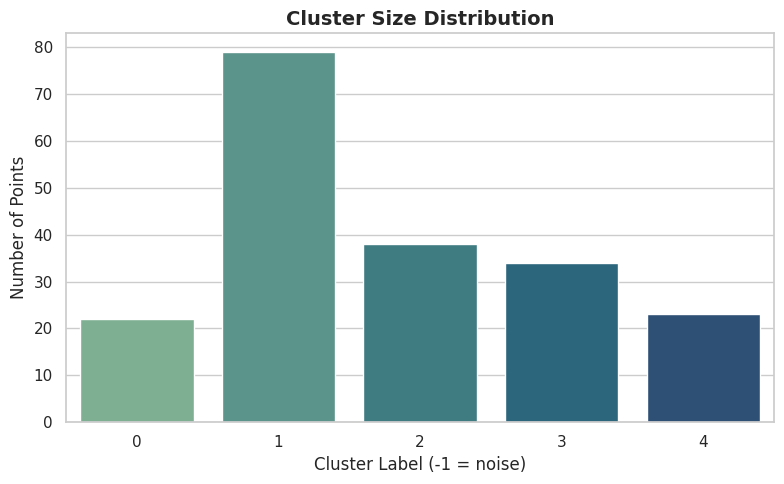

In [120]:
if PROBLEM_TYPE == "clustering":
    cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
    plt.figure(figsize=(8, 5))
    sns.barplot(x=cluster_sizes.index.astype(str), y=cluster_sizes.values, hue=cluster_sizes.index.astype(str),
                palette="crest", legend=False)
    plt.title("Cluster Size Distribution", fontsize=14, weight="bold")
    plt.xlabel("Cluster Label (-1 = noise)"); plt.ylabel("Number of Points")
    plt.tight_layout()
    plt.show()

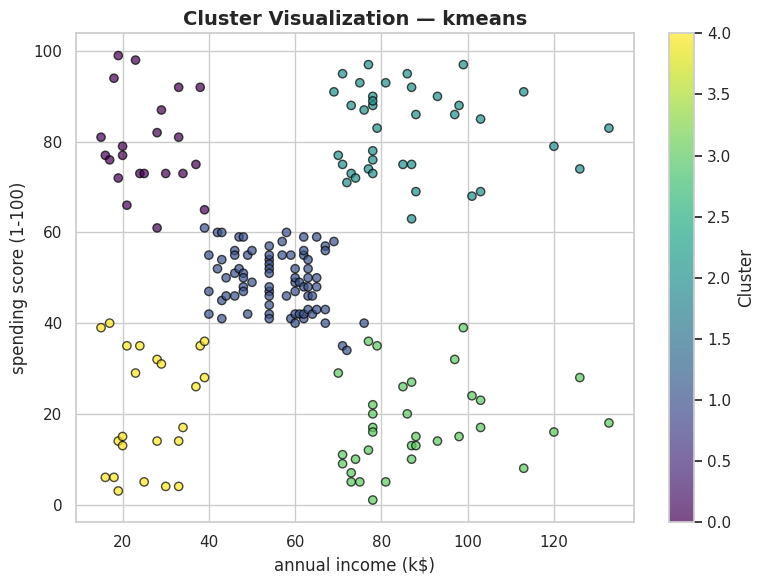

In [121]:
if PROBLEM_TYPE == "clustering":
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=cluster_labels, cmap="viridis", alpha=0.7, edgecolor="black")
    plt.title(f"Cluster Visualization — {ALGORITHM_NAME}", fontsize=14, weight="bold")
    plt.xlabel(df.columns[0]); plt.ylabel(df.columns[1])
    plt.colorbar(scatter, label="Cluster")
    plt.tight_layout()
    plt.show()

### 3D Cluster Visualization

In [122]:
if PROBLEM_TYPE == "clustering":
    print("Only 2 features used (Annual Income, Spending Score) — 3D visualization not applicable.")

Only 2 features used (Annual Income, Spending Score) — 3D visualization not applicable.


### Cluster Profiling
Average feature values per cluster — helps interpret what each cluster represents in business terms.

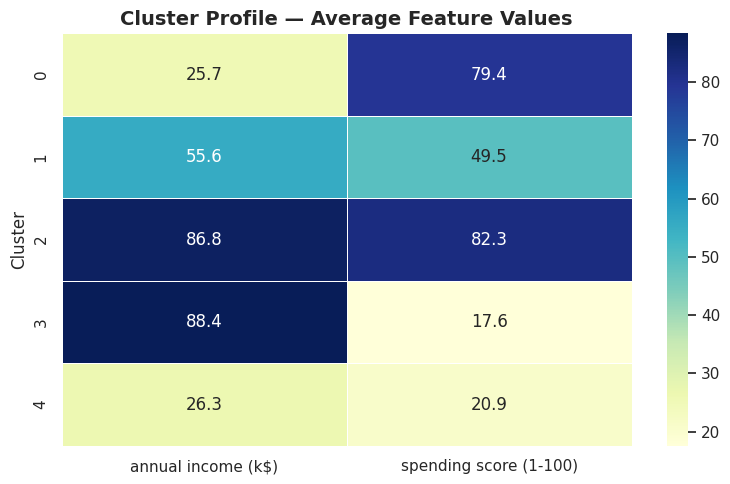

In [123]:
if PROBLEM_TYPE == "clustering" and numeric_features:
    profile_df = df[numeric_features].copy()
    profile_df["Cluster"] = cluster_labels
    cluster_profile = profile_df[profile_df["Cluster"] != -1].groupby("Cluster").mean().round(2)
    plt.figure(figsize=(max(8, len(numeric_features) * 1.2), max(5, cluster_profile.shape[0] * 0.6)))
    sns.heatmap(cluster_profile, annot=True, cmap="YlGnBu", fmt=".1f", linewidths=0.5)
    plt.title("Cluster Profile — Average Feature Values", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()
    cluster_profile
else:
    print("Cluster profiling requires numeric features and a clustering problem type — skipped.")

In [124]:
if PROBLEM_TYPE == "clustering" and ALGORITHM_NAME == "hierarchical":
    sample_for_dendro = X_processed[:50] if len(X_processed) > 50 else X_processed
    linked = linkage(sample_for_dendro, method="ward")
    plt.figure(figsize=(10, 6))
    dendrogram(linked, truncate_mode="lastp", p=20)
    plt.title("Dendrogram (Hierarchical Clustering, sample of 50)", fontsize=14, weight="bold")
    plt.xlabel("Sample Index"); plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()

In [125]:
if PROBLEM_TYPE == "dimensionality_reduction":
    plt.figure(figsize=(8, 6))
    plt.scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.7, color=COLOR_CYCLE[0], edgecolor="black")
    plt.title(f"2D Projection — {ALGORITHM_NAME}", fontsize=14, weight="bold")
    plt.xlabel("Component 1"); plt.ylabel("Component 2")
    plt.tight_layout()
    plt.show()

In [126]:
if PROBLEM_TYPE == "dimensionality_reduction" and hasattr(selected_algorithm, "explained_variance_ratio_"):
    evr = selected_algorithm.explained_variance_ratio_
    plt.figure(figsize=(8, 5))
    plt.bar(range(1, len(evr) + 1), evr, color=COLOR_CYCLE[1], alpha=0.8, label="Individual")
    plt.plot(range(1, len(evr) + 1), np.cumsum(evr), color=COLOR_CYCLE[5], marker="o", label="Cumulative")
    plt.title("Explained Variance Ratio", fontsize=14, weight="bold")
    plt.xlabel("Component"); plt.ylabel("Explained Variance Ratio"); plt.legend()
    plt.tight_layout()
    plt.show()
elif PROBLEM_TYPE == "dimensionality_reduction":
    print(f"'{ALGORITHM_NAME}' does not expose explained_variance_ratio_ (non-linear method).")

## 📐 12. Hyperparameter Tuning
Automatically tunes the most relevant parameter for the selected algorithm.

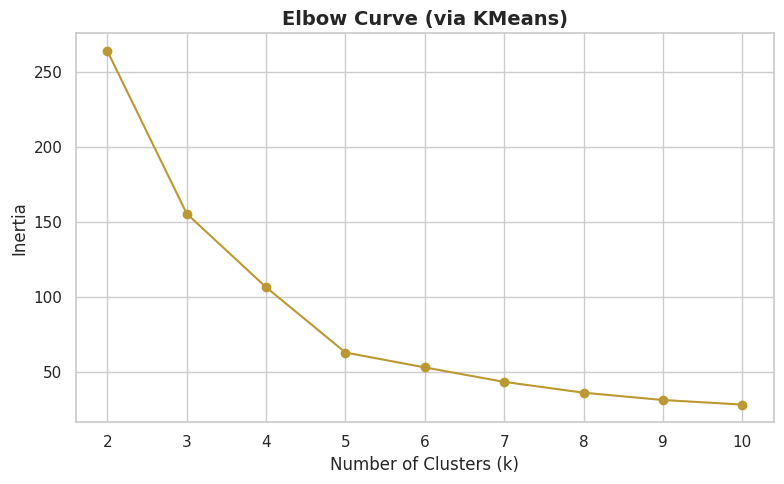

In [127]:
CLUSTER_COUNT_ALGORITHMS = ["kmeans", "hierarchical", "birch", "gmm", "spectral"]

if PROBLEM_TYPE == "clustering" and ALGORITHM_NAME in CLUSTER_COUNT_ALGORITHMS:
    k_range = range(2, 11)
    inertias, sil_scores = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10).fit(X_processed)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(X_processed, km.labels_))
    plt.figure(figsize=(8, 5))
    plt.plot(list(k_range), inertias, marker="o", color=COLOR_CYCLE[2])
    plt.title("Elbow Curve (via KMeans)", fontsize=14, weight="bold")
    plt.xlabel("Number of Clusters (k)"); plt.ylabel("Inertia")
    plt.tight_layout()
    plt.show()

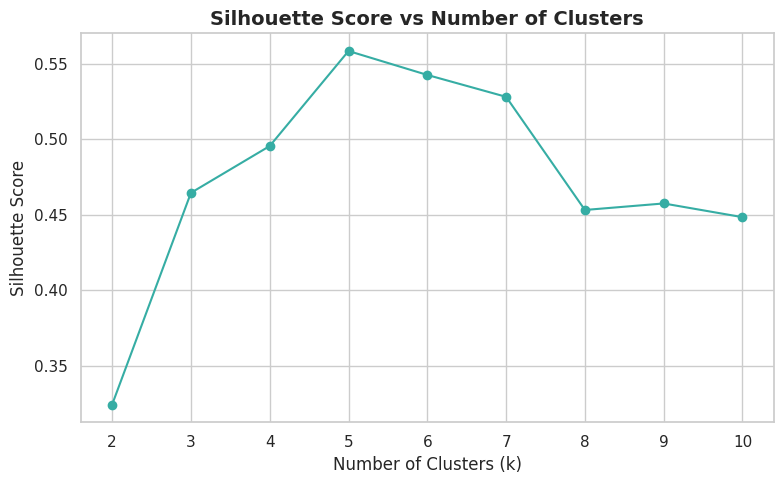

Best number of clusters (by silhouette score): 5


In [128]:
if PROBLEM_TYPE == "clustering" and ALGORITHM_NAME in CLUSTER_COUNT_ALGORITHMS:
    plt.figure(figsize=(8, 5))
    plt.plot(list(k_range), sil_scores, marker="o", color=COLOR_CYCLE[6])
    plt.title("Silhouette Score vs Number of Clusters", fontsize=14, weight="bold")
    plt.xlabel("Number of Clusters (k)"); plt.ylabel("Silhouette Score")
    plt.tight_layout()
    plt.show()
    best_k = list(k_range)[np.argmax(sil_scores)]
    print(f"Best number of clusters (by silhouette score): {best_k}")

In [129]:
if PROBLEM_TYPE == "clustering" and ALGORITHM_NAME == "dbscan":
    eps_range = [0.3, 0.5, 0.8, 1.0, 1.5, 2.0]
    dbscan_results = {}
    for eps in eps_range:
        labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_processed)
        mask = labels != -1
        n_found = len(set(labels[mask]))
        if n_found >= 2 and mask.sum() > n_found:
            dbscan_results[eps] = silhouette_score(X_processed[mask], labels[mask])
        else:
            dbscan_results[eps] = None
    print("DBSCAN eps tuning (silhouette score):")
    for eps, score in dbscan_results.items():
        print(f"  eps={eps}: {score if score is not None else 'N/A (too few clusters)'}")

In [130]:
if PROBLEM_TYPE == "clustering" and ALGORITHM_NAME not in CLUSTER_COUNT_ALGORITHMS + ["dbscan"]:
    print(f"'{ALGORITHM_NAME}' determines its structure automatically — no manual tuning required.")
elif PROBLEM_TYPE == "dimensionality_reduction":
    print(f"For '{ALGORITHM_NAME}', n_components=2 was used for visualization. "
          f"Increase n_components in the algorithm registry for downstream modeling use.")

## ✅ 14. Conclusion

In [133]:
print("="*50)
print("PIPELINE SUMMARY")
print("="*50)
print(f"Dataset: {DATA_PATH}")
print(f"Problem Type: {PROBLEM_TYPE}")
print(f"Algorithm Used: {ALGORITHM_NAME}")
if PROBLEM_TYPE == "clustering":
    print(f"Clusters Found: {n_clusters_found}")
    if unique_valid_clusters >= 2:
        print(f"Silhouette Score: {sil_score:.4f}")
else:
    print(f"Reduced Dimensions: {reduced_data.shape[1]}")
print("="*50)

PIPELINE SUMMARY
Dataset: /content/Mall_Customers.csv
Problem Type: clustering
Algorithm Used: kmeans
Clusters Found: 5
Silhouette Score: 0.5584


## 🔑 Key Insights

[The optimal number of customer segments was found to be 5, confirmed by testing a range of cluster counts and selecting the one with the highest silhouette score]

[A silhouette score of 0.5584 indicates moderately well-separated clusters — not perfectly distinct, but with clear structure (scores above 0.5 are generally considered reasonable for real-world customer data)]

[Since only Annual Income and Spending Score were used, the resulting 5 segments likely correspond to intuitive customer types such as: high income/high spending, high income/low spending, low income/high spending, low income/low spending, and an average-income/average-spending middle segment]
